# Account Intelligence — Exploratory Data Analysis

Goal: Design a **prioritization score** (which accounts need attention) and know what context to feed an LLM for **meeting-prep insights**. Hence, we're trying to find the 3-4 signals that actually matter, and check that our reasoning holds up against the data.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 20)


## Load Data

`region` has a category literally called `"NA"` (North America). Pandas' default
`read_csv` treats the string `"NA"` as a *missing value marker*, so a naive load makes it
look like those accounts have no region. We fix that by turning off pandas' default NA
sniffing and only treating true empty strings as missing.


In [6]:
# Correct load
df = pd.read_csv('../data/account_data.csv', keep_default_na=False, na_values=[''])

# numeric columns still need real NaN for true blanks, so we re-cast
num_cols = ['nr_employees','days_to_next_renewal','days_since_last_sales_activity',
            'nr_support_tickets','ai_usage','nr_active_users','nr_licensed_seats',
            'current_revenue','revenue_end_of_quarter']
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

print(df.shape)
df.head(5)

(1000, 16)


,account_id,account_name,account_description,industry,segment,region,nr_employees,days_to_next_renewal,days_since_last_sales_activity,nr_support_tickets,ai_usage,nr_active_users,nr_licensed_seats,current_revenue,call_transcript_summary,revenue_end_of_quarter
0,ACC-0001,Bolt Tech Ventures,Builds developer productivity platforms with i...,Technology,SMB,APAC,53,33,58.0,0,0.584,12,18,9761.87,Expansion conversation initiated by Head of Op...,12610.70
1,ACC-0002,Jade Campus AI,Builds virtual classroom tools with real-time ...,Education,SMB,LATAM,174,143,139.0,11,0.215,7,18,15737.37,"Check-in with VP of Sales. Steady usage, no co...",15737.37
2,ACC-0003,Wave Alloy Dynamics,Manufactures steel structural components for c...,Manufacturing,SMB,NA,196,183,49.0,3,0.261,5,16,3525.95,Mid-quarter sync. Director of Engineering is h...,3525.95
3,ACC-0004,Nexus Shelf Solutions,Provides inventory management and demand forec...,Retail,Mid-Market,EMEA,1178,206,69.0,2,0.659,56,94,81870.34,Client running an internal case study on our i...,115933.13
4,ACC-0005,Delta Deal Analytics,Builds retail analytics dashboards tracking fo...,Retail,Mid-Market,APAC,1869,248,1.0,2,0.496,156,173,78667.59,Exciting call with CTO. They want to roll out ...,97106.52


## Data Quality Checks


### Missing Values

In [7]:
# Missing values
missing = df.isna().sum()
missing = missing[missing > 0]
print(missing)
print()
print("% of rows with missing values:")
print((missing/len(df)*100).round(1))


days_since_last_sales_activity    20
ai_usage                          30
call_transcript_summary           52
dtype: int64

% of rows with missing values:
days_since_last_sales_activity    2.0
ai_usage                          3.0
call_transcript_summary           5.2
dtype: float64


In [8]:
# Snapshot before imputation - used below to check whether missingness itself
# correlates with outcome (i.e. whether dropping these rows would be safe).
df_raw = df.copy()
df_raw['revenue_delta_pct'] = (df_raw['revenue_end_of_quarter'] - df_raw['current_revenue']) / df_raw['current_revenue']


**Decisions:**
- On the columns `days_since_last_sales_activity` (2%) and `ai_usage` (3%) we will impute the missing values with the segment/industry/region (categorical columns used to group data by account) median. Both can feed a scoring model, so we shouldn't silently drop rows or zero-fill (zero would wrongly look like "very recent contact" and "zero AI adoption"). 
- On the column `call_transcript_summary` (5.2%) the missing values look like real gap, not a data error. In the app we just tell the LLM "no recent call notes available" rather than inventing content.


#### Imputation grouping selection

Segment, industry, and region are all candidate groupings. A grouping is only useful for imputation if the group median is actually a better guess than the global median — i.e. the column's values genuinely differ across that grouping. We check this with eta-squared (share of variance in the column explained by the grouping): higher is better.


In [9]:
def eta_squared(df, group_col, target_col):
    """Share of variance in target_col explained by group_col (0=no relationship, 1=perfect)."""
    sub = df[[group_col, target_col]].dropna()
    grand_mean = sub[target_col].mean()
    ss_total = ((sub[target_col] - grand_mean) ** 2).sum()
    ss_between = sub.groupby(group_col)[target_col].apply(
        lambda x: len(x) * (x.mean() - grand_mean) ** 2
    ).sum()
    return ss_between / ss_total

for target in ['days_since_last_sales_activity', 'ai_usage']:
    for g in ['segment', 'industry', 'region']:
        print(f"{target:35s} grouped by {g:10s} -> eta^2 = {eta_squared(df, g, target):.4f}")


days_since_last_sales_activity      grouped by segment    -> eta^2 = 0.0056
days_since_last_sales_activity      grouped by industry   -> eta^2 = 0.0396
days_since_last_sales_activity      grouped by region     -> eta^2 = 0.0024
ai_usage                            grouped by segment    -> eta^2 = 0.0000
ai_usage                            grouped by industry   -> eta^2 = 0.0213
ai_usage                            grouped by region     -> eta^2 = 0.0012


In [14]:
for g in ['segment', 'industry', 'region']:
    print(df.groupby(g)["days_since_last_sales_activity"].describe())
    print(df.groupby(g)["ai_usage"].describe())
    print('---')

            count       mean        std  min   25%   50%    75%    max
segment                                                               
Enterprise  205.0  59.209756  34.458698  0.0  36.0  58.0  84.00  150.0
Mid-Market  389.0  63.362468  36.578467  0.0  38.0  63.0  87.00  180.0
SMB         386.0  66.619171  38.247690  0.0  39.0  65.0  94.75  180.0
            count      mean       std  min      25%     50%      75%    max
segment                                                                    
Enterprise  206.0  0.327903  0.242753  0.0  0.07975  0.3355  0.51725  0.938
Mid-Market  386.0  0.323614  0.249684  0.0  0.10325  0.3145  0.50300  1.000
SMB         378.0  0.324910  0.248519  0.0  0.08850  0.3165  0.51225  0.951
---
               count       mean        std  min    25%   50%    75%    max
industry                                                                  
Education      163.0  62.680982  38.791418  0.0  33.50  61.0  91.50  155.0
Finance        120.0  63.833333  36.

**Result: industry is the right grouping.**

| Column | by segment | by industry | by region |
|---|---|---|---|
| `days_since_last_sales_activity` | 0.0056 | **0.0396** | 0.0024 |
| `ai_usage` | 0.0000 | **0.0213** | 0.0012 |

Segment and region explain almost none of the variance in either column —
their medians are nearly identical across segments. Industry explains 4-20x more: e.g.
Technology accounts have a median of 52 days since last contact vs. Manufacturing's 75, and
39% AI usage vs. Healthcare's 23%. Those are real, usable differences.

In [15]:
# Imputation grouped by industry
df['ai_usage'] = df.groupby('industry')['ai_usage'].transform(lambda s: s.fillna(s.median()))
df['days_since_last_sales_activity'] = df.groupby('industry')['days_since_last_sales_activity'].transform(lambda s: s.fillna(s.median()))

# Create transcript flag for the LLM
df['has_transcript'] = df['call_transcript_summary'].notna()

print("Remaining missing (excluding transcript, which we keep as a flag):")
print(df.drop(columns=['call_transcript_summary']).isna().sum().sum())


Remaining missing (excluding transcript, which we keep as a flag):
0


### Duplicates

In [16]:
# Check if any duplicate rows exist
has_duplicates = df.duplicated().any()

print(f"Duplicates found: {has_duplicates}")

pk_col = "account_id"
is_valid_pk = df[pk_col].nunique(dropna=False) == len(df)
print(f"Primary key has unique values for every row: {is_valid_pk}")

Duplicates found: False
Primary key has unique values for every row: True


## Exploratory Data Analysis

### Shape of the business

Quick look at how accounts are distributed across segment, industry, region, and revenue — this tells us whether the scoring logic needs to normalize *within* groups (e.g. an Enterprise account naturally has more employees/seats than an SMB one).


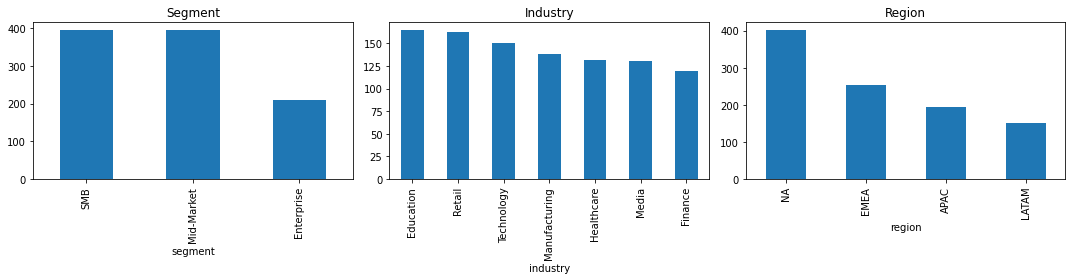

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df['segment'].value_counts().plot(kind='bar', ax=axes[0], title='Segment')
df['industry'].value_counts().plot(kind='bar', ax=axes[1], title='Industry')
df['region'].value_counts().plot(kind='bar', ax=axes[2], title='Region')
plt.tight_layout()
plt.savefig('segment_industry_region.png', dpi=100)
plt.show()


In [19]:
df.describe()

,nr_employees,days_to_next_renewal,days_since_last_sales_activity,nr_support_tickets,ai_usage,nr_active_users,nr_licensed_seats,current_revenue,revenue_end_of_quarter
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1.000000e+03
mean,6145.629000,148.717000,63.763000,4.198000,0.325149,166.010000,276.580000,2.465006e+05,2.548995e+05
std,12429.088901,69.403702,36.539896,3.091983,0.243918,307.848555,483.397154,4.749331e+05,5.247282e+05
min,10.000000,30.000000,0.000000,0.000000,0.000000,1.000000,5.000000,2.057740e+03,0.000000e+00
25%,123.750000,92.000000,39.000000,2.000000,0.102500,16.000000,31.000000,1.333361e+04,1.051455e+04
50%,733.500000,150.000000,62.000000,4.000000,0.320500,37.000000,69.000000,4.193779e+04,3.395415e+04
75%,1855.000000,208.000000,87.000000,6.000000,0.503250,105.000000,173.000000,9.046299e+04,9.301279e+04
max,49974.000000,270.000000,180.000000,15.000000,1.000000,1796.000000,1997.000000,1.991500e+06,2.631825e+06


In [18]:
print(df.groupby('segment')[['nr_employees','nr_licensed_seats','current_revenue']].median())


            nr_employees  nr_licensed_seats  current_revenue
segment                                                     
Enterprise       26919.0             1040.0      1025568.765
Mid-Market        1164.0              104.0        59038.090
SMB                 98.0               26.0        10834.970


Confirms segments are genuinely different populations (Enterprise accounts are much
bigger on every axis). Any score that compares raw counts across segments would just be
re-discovering "Enterprise > SMB" rather than telling an AE something useful. We'll normalize
(percentile rank) *within* segment for anything employee/seat-scale-dependent.


**One more check before trusting the scoring inputs at face value:** `nr_support_tickets`
is a raw count, and big companies could plausibly generate more tickets just by having more
employees/seats — which would make "high ticket count" a proxy for "large account," not for
"unhealthy account." If that were true, we'd need to normalize tickets per-seat before using
it as a risk signal. Checking directly:


In [11]:
print("corr(nr_support_tickets, nr_employees):", df['nr_support_tickets'].corr(df['nr_employees']).round(3))
print("corr(nr_support_tickets, nr_licensed_seats):", df['nr_support_tickets'].corr(df['nr_licensed_seats']).round(3))
print()
print("median tickets by segment:")
print(df.groupby('segment')['nr_support_tickets'].median())


corr(nr_support_tickets, nr_employees): -0.053
corr(nr_support_tickets, nr_licensed_seats): -0.053

median tickets by segment:
segment
Enterprise    3.0
Mid-Market    4.0
SMB           4.0
Name: nr_support_tickets, dtype: float64


Correlation is essentially zero (~-0.05) and the median ticket count is nearly flat across
Enterprise/Mid-Market/SMB (3-4 tickets regardless of size). So `nr_support_tickets` isn't a
disguised size effect — an Enterprise account isn't flagged "at risk" just for being big


### Revenue

The dataset gives us `current_revenue` and `revenue_end_of_quarter`. Money value is the ultimate goal for every AE, hence revenue is the main outcome. We treat the delta as a **stand-in for account health outcome** — useful for sanity-checking our score, but we will **not** feed it into the score itself (that would be circular as we're trying to predict/flag this).

In [20]:
df['revenue_delta_pct'] = (df['revenue_end_of_quarter'] - df['current_revenue']) / df['current_revenue']
df['seat_utilization'] = df['nr_active_users'] / df['nr_licensed_seats']

print(df['revenue_delta_pct'].describe())
print()
print(f"Shrinking (>1% down): {(df['revenue_delta_pct'] < -0.01).sum()}")
print(f"Flat:                 {(df['revenue_delta_pct'].abs() <= 0.01).sum()}")
print(f"Growing (>1% up):     {(df['revenue_delta_pct'] > 0.01).sum()}")


count    1000.000000
mean       -0.014467
std         0.362415
min        -1.000000
25%         0.000000
50%         0.000000
75%         0.176908
max         0.497213
Name: revenue_delta_pct, dtype: float64

Shrinking (>1% down): 110
Flat:                 592
Growing (>1% up):     298


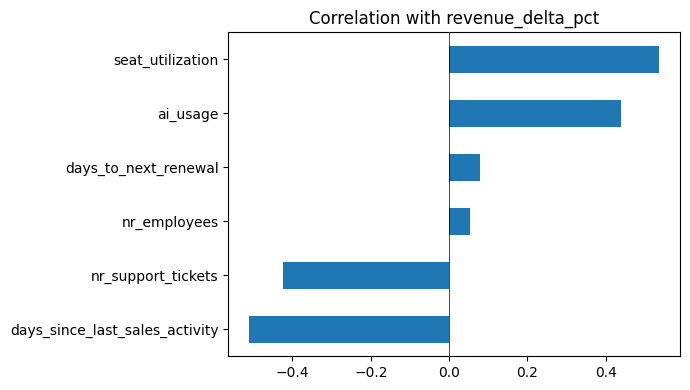

days_since_last_sales_activity   -0.511203
nr_support_tickets               -0.423561
nr_employees                      0.052162
days_to_next_renewal              0.079599
ai_usage                          0.438111
seat_utilization                  0.536948
Name: revenue_delta_pct, dtype: float64


In [13]:
candidate_features = ['days_since_last_sales_activity', 'nr_support_tickets',
                      'ai_usage', 'seat_utilization', 'days_to_next_renewal', 'nr_employees']
corr = df[candidate_features + ['revenue_delta_pct']].corr()['revenue_delta_pct'].drop('revenue_delta_pct')
corr.sort_values().plot(kind='barh', figsize=(7,4), title='Correlation with revenue_delta_pct')
plt.axvline(0, color='k', linewidth=0.5)
plt.tight_layout()
plt.savefig('correlations.png', dpi=100)
plt.show()
print(corr.sort_values())


**This is the key finding.** Four features move together with revenue outcome, two ways:

| Direction | Feature | Correlation | Read |
|---|---|---|---|
| Risk ↑ | `days_since_last_sales_activity` | ~ -0.51 | Longer since we talked to them → revenue shrinks |
| Risk ↑ | `nr_support_tickets` | ~ -0.42 | More open tickets → revenue shrinks |
| Opportunity ↑ | `ai_usage` | ~ +0.44 | More AI feature adoption → revenue grows |
| Opportunity ↑ | `seat_utilization` | ~ +0.54 | More of their seats actually used → revenue grows |

`nr_employees` and `days_to_next_renewal` on their own barely correlate with outcome — but
`days_to_next_renewal` still matters as an **urgency multiplier**: a risky account renewing
in 20 days needs attention *now*, the same risk profile renewing in 200 days can wait.

This gives us an explainable, four-input score instead of a black box.


## Scoring Model

Our scoring model is divided into 3 compounds:
- **Risk score** (0-1): normalized blend of `days_since_last_sales_activity` (higher=worse)
  and `nr_support_tickets` (higher=worse).
- **Opportunity score** (0-1): normalized blend of `ai_usage` and `seat_utilization`
  (higher=better).
- **Urgency** (0-1): inverse of `days_to_next_renewal` — renewals coming up soon matter more.


**Priority score** = `urgency * max(risk, opportunity)` — surfaces accounts where
  something is happening (good or bad) *and* it's time-sensitive. A calm, flat account
  renewing far out sinks to the bottom, while a volatile account with a renewal next week rises
  to the top, whether the story is "about to churn" or "ready to expand."

We percentile-rank (percentage of observations less than or equal to a given value) each raw input (0-1) instead of min-max scaling, so segment-size outliers (e.g. one huge Enterprise account) don't distort everyone else's score. 


In [21]:
def pct_rank(s):
    return s.rank(pct=True)

# Multiply by 0.5 as there are 2 variables on compound risk and opportunity, each weight the same (keeping results between [0,1])
df['risk_raw']   = pct_rank(df['days_since_last_sales_activity']) * 0.5 + pct_rank(df['nr_support_tickets']) * 0.5
df['opp_raw']    = pct_rank(df['ai_usage']) * 0.5 + pct_rank(df['seat_utilization']) * 0.5
df['urgency']    = 1 - pct_rank(df['days_to_next_renewal'])

df['priority_score'] = df['urgency'] * df[['risk_raw','opp_raw']].max(axis=1)
df['flag'] = np.where(df['risk_raw'] >= df['opp_raw'], 'At Risk', 'Growth Opportunity')

df[['account_id','account_name','segment','risk_raw','opp_raw','urgency','priority_score','flag']]\
.sort_values('priority_score', ascending=False).head(15)


,account_id,account_name,segment,risk_raw,opp_raw,urgency,priority_score,flag
932,ACC-0933,Vivid Gene Studio,Enterprise,0.98725,0.22225,0.9485,0.936407,At Risk
680,ACC-0681,Jade Edu Hub,SMB,0.96050,0.15500,0.9675,0.929284,At Risk
471,ACC-0472,Zeta Edu AI,Enterprise,0.13175,0.93950,0.9780,0.918831,Growth Opportunity
987,ACC-0988,Nova Wealth Solutions,Mid-Market,0.90775,0.39850,0.9970,0.905027,At Risk
26,ACC-0027,Prism Fund Co,SMB,0.91900,0.13000,0.9845,0.904756,At Risk
64,ACC-0065,Wave Fin IO,SMB,0.95975,0.15875,0.9405,0.902645,At Risk
262,ACC-0263,Helix Wealth Global,Enterprise,0.21875,0.90525,0.9845,0.891219,Growth Opportunity
219,ACC-0220,Prism Story Dynamics,SMB,0.17650,0.88800,0.9845,0.874236,Growth Opportunity
173,ACC-0174,Beta Study Analytics,SMB,0.98475,0.11175,0.8695,0.856240,At Risk
806,ACC-0807,Prism Deal Partners,Mid-Market,0.95025,0.09350,0.8970,0.852374,At Risk


In [29]:
print(df.priority_score.describe())

print(df.groupby("flag")["priority_score"].describe())

count    1000.000000
mean        0.343803
std         0.218158
min         0.001510
25%         0.171923
50%         0.316912
75%         0.504362
max         0.936407
Name: priority_score, dtype: float64
                    count      mean       std       min       25%       50%       75%       max
flag                                                                                           
At Risk             506.0  0.358013  0.222552  0.001510  0.176721  0.333966  0.510503  0.936407
Growth Opportunity  494.0  0.329249  0.212805  0.001774  0.150092  0.302570  0.496818  0.918831


### Sanity check

`revenue_delta_pct` is **not** an input to the score on purpose. If our score is reasonable,
high-priority "At Risk" accounts should skew toward negative revenue delta, and high-priority
"Growth Opportunity" accounts should skew positive.


In [34]:
top_risk = df[df['flag']=='At Risk'].sort_values('priority_score', ascending=False).head(100)
top_opp  = df[df['flag']=='Growth Opportunity'].sort_values('priority_score', ascending=False).head(100)

print("Top 100 'At Risk' accounts - avg revenue_delta_pct:", top_risk['revenue_delta_pct'].mean().round(3))
print("Top 100 'Growth Opportunity' accounts - avg revenue_delta_pct:", top_opp['revenue_delta_pct'].mean().round(3))
print("Overall average of revenue_delta_pct:", df['revenue_delta_pct'].mean().round(3))


Top 100 'At Risk' accounts - avg revenue_delta_pct: -0.363
Top 100 'Growth Opportunity' accounts - avg revenue_delta_pct: 0.219
Overall average of revenue_delta_pct: -0.014


The gap between these three numbers is the validation: risk-flagged accounts should
average well below the overall mean, opportunity-flagged accounts well above it. That's our
evidence the score isn't arbitrary — it's picking up the same signal that shows up in actual
revenue movement, without ever seeing that number.
